## Urban Equity Index (UEI) for Vilnius

## Overview

**Green for All LT** analyzes **urban equity and accessibility** across **Vilnius elderships (seniūnijos)** by integrating environmental, social, transport, and infrastructure data into a unified **Urban Equity Index (UEI)**.

The project identifies neighborhoods where **low urban equity intersects with limited access to green spaces, public transport, services, and waste infrastructure**, supporting evidence-based urban planning, public health policy, and EU Green City objectives.

---

## Core Research Questions

- Which elderships in Vilnius experience **structural urban disadvantage**?
- How does access to **green space, transport, services, and waste infrastructure** vary across the city?
- Where do **high social vulnerability and poor accessibility overlap**?
- How can a composite index support **transparent prioritization of urban interventions**?

In [342]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import scipy.stats as stats

from shapely.geometry import Point
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import KernelDensity, BallTree
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

pd.set_option("display.max_columns", None)


## 1. Data Sources

| Type | Source | Description | Format |
|------|--------|------------|--------|
| **Administrative Boundaries** | Vilnius Data Portal (vplanas.lt) | Official eldership boundaries | GeoJSON |
| **Demographics & Socioeconomics** | Statistics Lithuania (stat.gov.lt) | Population, density, age structure, unemployment, income | CSV |
| **Green & Public Amenities (Live API)** | OSM / Municipal datasets | Green areas, education, health, cultural facilities | CSV / GeoJSON |
| **Transport Infrastructure (Live API)** | Vilnius GIS Services | Bus stops (real-time API) | REST / GeoJSON |
| **Environmental Data** | Municipal / Public datasets | PM2.5, NO₂ air pollution | CSV |
| **Waste Infrastructure** | Vilnius Open Data | Waste container locations | GeoJSON |
| **Benchmarks** | WHO / Eurostat | Green space standards (≥0.5 ha / 1,000 residents) | Guidelines |

> All data sources are **open, public, and license-compliant**.

In [343]:
METRICS_CSV = Path("../data/processed/full_metrics.csv")
ELDERSHIPS_GEOJSON = Path("../data/processed/eldership_equity_metrics.geojson")
WASTE_CONTAINERS_GEOJSON = Path("../data/raw/waste_containers_vilnius.geojson")
OUT_DIR = Path("../data/processed")
DOCS_DIR = Path("../docs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

In [344]:
df_metrics = pd.read_csv(METRICS_CSV)

if "Eldership" in df_metrics.columns and "SENIUNIJA" not in df_metrics.columns:
    df_metrics = df_metrics.rename(columns={"Eldership": "SENIUNIJA"})

print(f"Loaded data for {len(df_metrics)} elderships")

# mapping for missing density in plots
if "density" not in df_metrics.columns and "Population_Density_people_ha" in df_metrics.columns:
    df_metrics["density"] = df_metrics["Population_Density_people_ha"]

Loaded data for 21 elderships


## 2. UEI + BALANCED EQUITY INDEX
#### 2.1 Normalization of Amenity Access Metrics

All per-capita access metrics are normalized to [0,1] scale (higher = better access). All per capita access metrics (e.g., green space, healthcare, education, and cultural facilities per 1,000 residents) are normalized to a [0,1] scale using Min-Max scaling. In this scale:

0 represents the lowest access in the dataset (worst), and
1 represents the highest access in the dataset (best).

This normalization ensures comparability across different metrics, which may originally have varying units and ranges. The sklearn.preprocessing.MinMaxScaler is used for this purpose, as it preserves the relative differences while bounding the values.
Why normalize? Without normalization, metrics with larger absolute values (e.g., green area per 1,000) could dominate the index calculation. This step promotes fairness in the composite indices.


In [345]:
scaler_amenities = MinMaxScaler()

amenity_cols = ["green_area_per_1000", "health_per_1000", "education_per_1000", "culture_per_1000"]
df_metrics[amenity_cols] = scaler_amenities.fit_transform(df_metrics[amenity_cols])

#### 2.2 Initial UEI Calculation

The Urban Equity Index (UEI) is a composite score balancing amenities and vulnerabilities:

- **UEI_raw**: Weighted sum of normalized amenities (green space: 0.4; health, education, culture: 0.2 each), prioritizing green areas for health/environmental equity.
- **Vulnerability Penalty**: Elderly % (0.15 weight) + unemployment rate (0.10 weight).
- **Adjusted UEI**: UEI_raw minus penalty, clipped to [0,1].
- **Normalized UEI**: Min-Max scaled for city-wide comparison; higher = better equity.

Additional metrics:
- **Employment Score**: Inverted/normalized unemployment rate [0,1], rewarding stability.
- **Balanced Equity Index**: Equal weights (0.25 each) for green, health, education, employment; focuses on positives without penalties.

Outputs & Enhancements:
- Rankings: Sorted descending for UEI and Balanced Index; saved as CSVs for decision-making (e.g., funding).
- Suggestions: Sensitivity analysis, thresholds (e.g., UEI < 0.5 = high priority), validation vs. external data (e.g., surveys).
- Builds on Section 1 preprocessed metrics for reproducibility.

In [346]:
weights = np.array([0.4, 0.2, 0.2, 0.2])  # green, health, education, culture
df_metrics["UEI_raw"] = df_metrics[amenity_cols].dot(weights)

df_metrics["vulnerability_penalty"] = (
    (df_metrics["% Elderly"] / 100 * 0.15) +
    (df_metrics["Unemployment Rate (%)"] / 100 * 0.10)
)

df_metrics["UEI"] = np.clip(df_metrics["UEI_raw"] - df_metrics["vulnerability_penalty"], 0, 1)

scaler_uei = MinMaxScaler()
df_metrics["UEI_normalized"] = scaler_uei.fit_transform(df_metrics[["UEI"]])

# employment_score
df_metrics["employment_score"] = 1 - (df_metrics["Unemployment Rate (%)"] / 100)
df_metrics["employment_score"] = MinMaxScaler().fit_transform(df_metrics[["employment_score"]])

df_metrics["balanced_equity_index"] = (
    df_metrics["green_area_per_1000"] * 0.25 +
    df_metrics["health_per_1000"] * 0.25 +
    df_metrics["education_per_1000"] * 0.25 +
    df_metrics["employment_score"] * 0.25
)

# rankings
uei_ranking = df_metrics[["SENIUNIJA", "UEI_normalized"]].sort_values("UEI_normalized", ascending=False)
balanced_ranking = df_metrics[["SENIUNIJA", "balanced_equity_index"]].sort_values("balanced_equity_index", ascending=False)

uei_ranking.to_csv(OUT_DIR / "uei_ranking.csv", index=False)
balanced_ranking.to_csv(OUT_DIR / "balanced_equity_ranking.csv", index=False)

print("UEI Ranking:")
print(uei_ranking)
print("\nBalanced Equity Ranking:")
print(balanced_ranking)


UEI Ranking:
         SENIUNIJA  UEI_normalized
0       Antakalnis        1.000000
9         Paneriai        0.875077
13     Senamiestis        0.871734
6     Naujamiestis        0.782978
20        Žvėrynas        0.551509
18       Šnipiškės        0.512703
12           Rasos        0.479178
16     Viršuliškės        0.325437
14         Verkiai        0.290807
11         Pilaitė        0.213883
15        Vilkpėdė        0.178118
2        Grigiškės        0.158181
19        Žirmūnai        0.154744
4     Karoliniškės        0.144914
5         Lazdynai        0.134688
3      Justiniškės        0.130585
7      Naujininkai        0.126749
8   Naujoji Vilnia        0.112526
17         Šeškinė        0.065937
1     Fabijoniškės        0.000165
10     Pašilaičiai        0.000000

Balanced Equity Ranking:
         SENIUNIJA  balanced_equity_index
6     Naujamiestis               0.654366
0       Antakalnis               0.574360
20        Žvėrynas               0.546423
18       Šnipiškės     

## 3. Dwelling Density and Urban Form

This section examines housing density and urban form characteristics across Vilnius elderships. Dwelling density, population density, building height, and green space coverage provide essential context for understanding urban intensity and livability trade-offs.

#### 3.1 Summary Statistics of Dwelling Metrics

Key dwelling and urban form indicators are extracted and summarized to describe their overall distribution.

In [347]:
df_dwelling = df_metrics.copy()

dwelling_cols = [
    "Dwelling_Density_dwellings_ha",
    "Population_Density_people_ha",
    "Building_Height_Stories",
    "Floor_Area_Ratio_FAR",
    "Green_Space_Percent"
]

dwelling_data = df_dwelling[dwelling_cols].dropna()
print("\nDwelling Metrics Summary Statistics")
print("=" * 80)
print(dwelling_data.describe().to_string())
print("=" * 80)


Dwelling Metrics Summary Statistics
       Dwelling_Density_dwellings_ha  Population_Density_people_ha  Floor_Area_Ratio_FAR  Green_Space_Percent
count                      14.000000                     14.000000             14.000000            14.000000
mean                       23.821429                     51.500000              1.137857            42.214286
std                        10.523978                     22.541415              0.661446            15.933412
min                         3.500000                      8.000000              0.120000            15.000000
25%                        17.250000                     37.500000              0.782500            32.750000
50%                        23.500000                     51.000000              1.025000            42.000000
75%                        28.500000                     61.000000              1.275000            51.000000
max                        44.000000                     95.000000              2.8

#### 3.2 Dwelling Density by Eldership

A horizontal bar chart visualizes variation in dwelling density across elderships, highlighting areas of compact and low-density development.

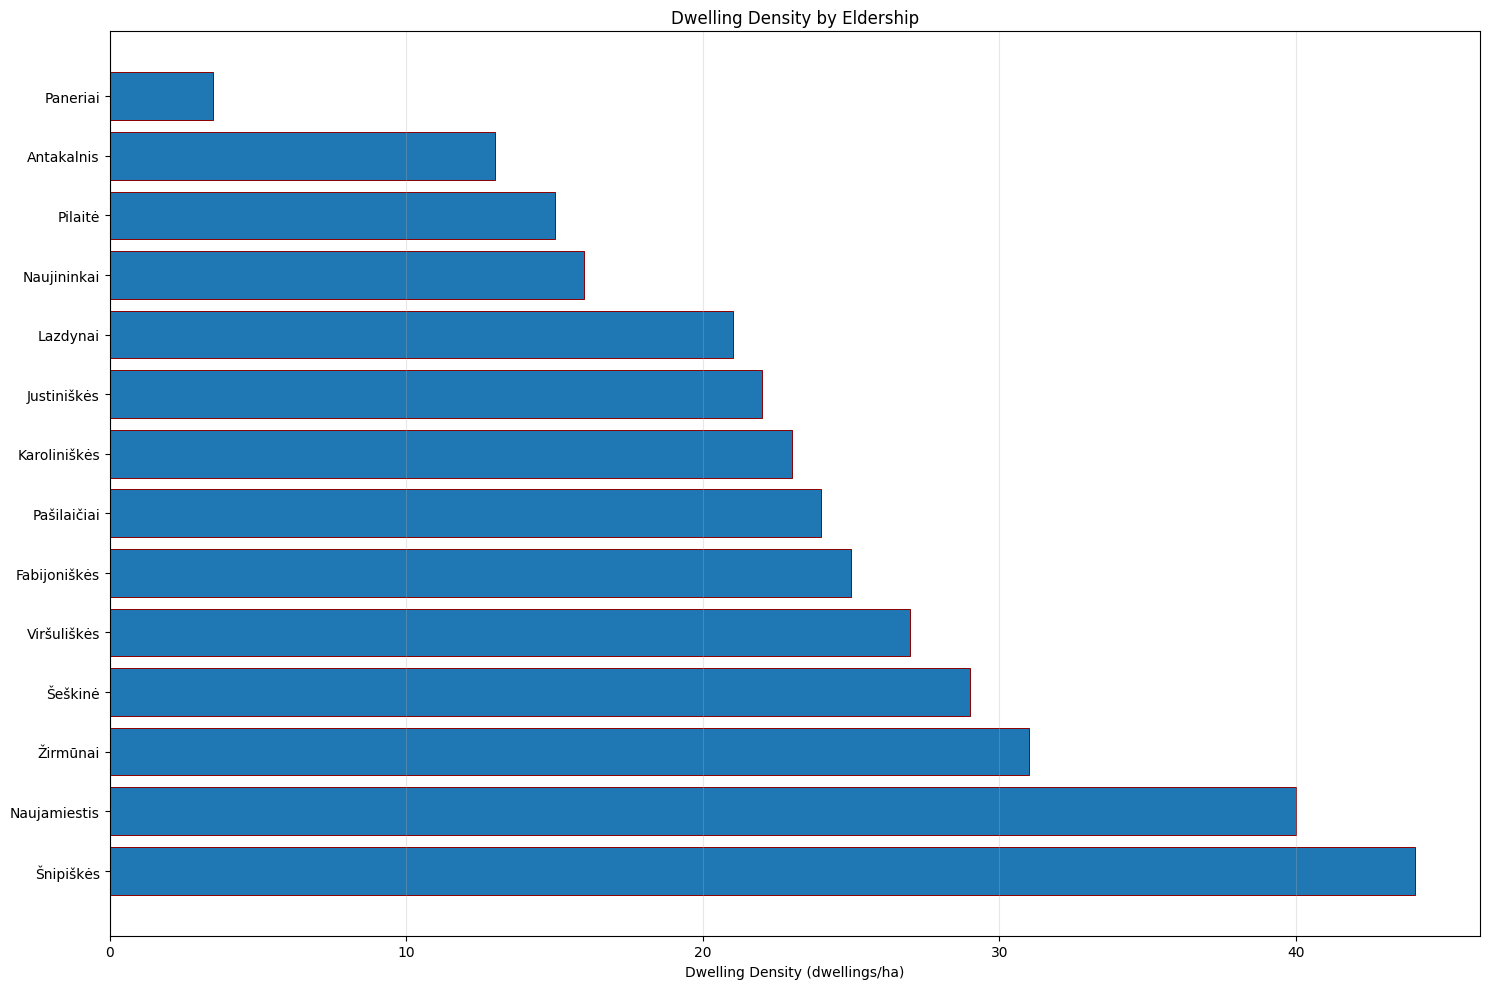

In [348]:
metrics_with_dwelling = df_dwelling.dropna(subset=["Dwelling_Density_dwellings_ha"]).copy()
metrics_with_dwelling_sorted = metrics_with_dwelling.sort_values("Dwelling_Density_dwellings_ha", ascending=False)

fig, ax = plt.subplots(figsize=(15, 10))
ax.barh(
    metrics_with_dwelling_sorted["SENIUNIJA"],
    metrics_with_dwelling_sorted["Dwelling_Density_dwellings_ha"],
    edgecolor="darkred",
    linewidth=0.7
)
ax.set_xlabel("Dwelling Density (dwellings/ha)")
ax.set_title("Dwelling Density by Eldership")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

#### 3.3 Dwelling vs Population Density

The relationship between dwelling density and population density is explored using a scatter plot, illustrating how residential form translates into population concentration.

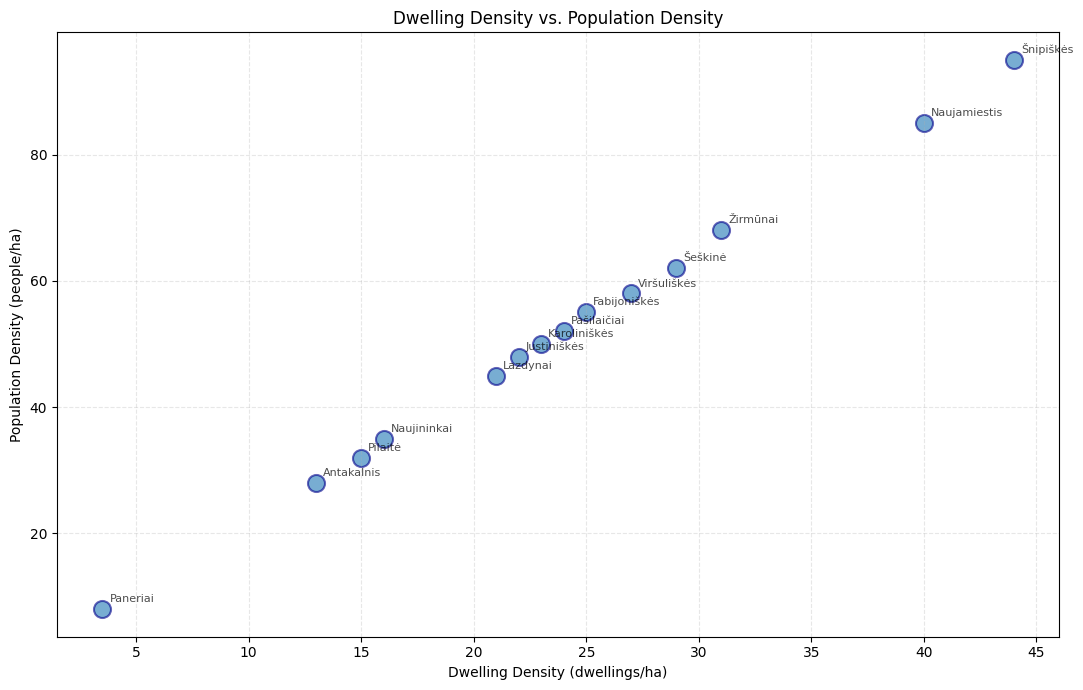

In [349]:
plot_data = df_dwelling.dropna(subset=["Dwelling_Density_dwellings_ha", "Population_Density_people_ha"]).copy()
if len(plot_data) > 0:
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.scatter(
        plot_data["Dwelling_Density_dwellings_ha"],
        plot_data["Population_Density_people_ha"],
        s=150,
        alpha=0.6,
        edgecolors="darkblue",
        linewidth=1.5
    )
    for _, row in plot_data.iterrows():
        ax.annotate(
            row["SENIUNIJA"],
            (row["Dwelling_Density_dwellings_ha"], row["Population_Density_people_ha"]),
            fontsize=8,
            alpha=0.7,
            xytext=(5, 5),
            textcoords="offset points"
        )
    ax.set_xlabel("Dwelling Density (dwellings/ha)")
    ax.set_ylabel("Population Density (people/ha)")
    ax.set_title("Dwelling Density vs. Population Density")
    ax.grid(True, alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()

#### 3.4 Extremes of Dwelling Density

The top and bottom elderships by dwelling density are reported to identify the most compact and most dispersed residential areas.

In [350]:
print("\nTOP 5 HIGHEST DWELLING DENSITY")
print("=" * 80)
top_5 = df_dwelling.nlargest(5, "Dwelling_Density_dwellings_ha")[
    ["SENIUNIJA", "Dwelling_Density_dwellings_ha", "Building_Height_Stories", "Green_Space_Percent"]
]
print(top_5.to_string(index=False))

print("\nBOTTOM 5 LOWEST DWELLING DENSITY")
print("=" * 80)
bottom_5 = df_dwelling.nsmallest(5, "Dwelling_Density_dwellings_ha")[
    ["SENIUNIJA", "Dwelling_Density_dwellings_ha", "Building_Height_Stories", "Green_Space_Percent"]
]
print(bottom_5.to_string(index=False))
print("=" * 80)


TOP 5 HIGHEST DWELLING DENSITY
   SENIUNIJA  Dwelling_Density_dwellings_ha Building_Height_Stories  Green_Space_Percent
   Šnipiškės                           44.0                    5-16                 15.0
Naujamiestis                           40.0                    6-12                 22.0
    Žirmūnai                           31.0                       9                 28.0
     Šeškinė                           29.0                       9                 32.0
 Viršuliškės                           27.0                       9                 35.0

BOTTOM 5 LOWEST DWELLING DENSITY
  SENIUNIJA  Dwelling_Density_dwellings_ha Building_Height_Stories  Green_Space_Percent
   Paneriai                            3.5                       2                 75.0
 Antakalnis                           13.0                     4.5                 62.0
    Pilaitė                           15.0                     4-6                 55.0
Naujininkai                           16.0      

#### 3.5 Distribution of Density Measures

Histograms summarize the overall distribution of dwelling density and population density across elderships, with mean and median values indicated.

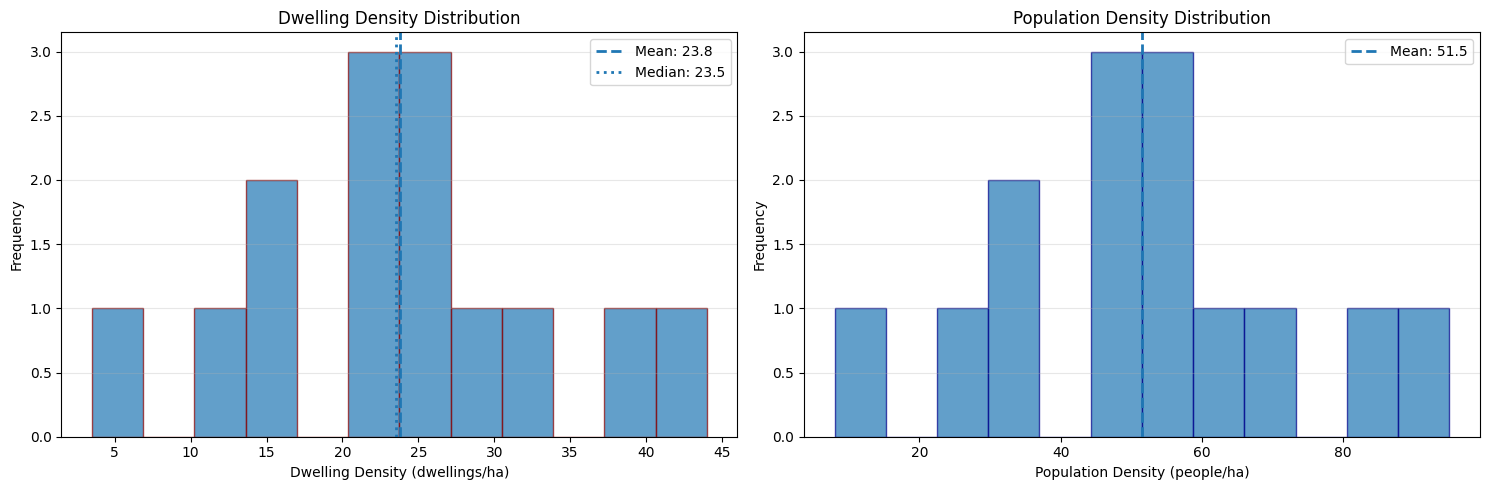

In [351]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

dwelling_dist = df_dwelling["Dwelling_Density_dwellings_ha"].dropna()
axes[0].hist(dwelling_dist, bins=12, alpha=0.7, edgecolor="darkred")
axes[0].axvline(dwelling_dist.mean(), linestyle="--", linewidth=2, label=f"Mean: {dwelling_dist.mean():.1f}")
axes[0].axvline(dwelling_dist.median(), linestyle=":", linewidth=2, label=f"Median: {dwelling_dist.median():.1f}")
axes[0].set_xlabel("Dwelling Density (dwellings/ha)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Dwelling Density Distribution")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

pop_dist = df_dwelling["Population_Density_people_ha"].dropna()
axes[1].hist(pop_dist, bins=12, alpha=0.7, edgecolor="darkblue")
axes[1].axvline(pop_dist.mean(), linestyle="--", linewidth=2, label=f"Mean: {pop_dist.mean():.1f}")
axes[1].set_xlabel("Population Density (people/ha)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Population Density Distribution")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Air Pollution and Socioeconomic Context

This section explores spatial variation in air pollution exposure across Vilnius elderships and examines its relationship with population density, green space availability, and socioeconomic vulnerability. Fine particulate matter (PM2.5) and nitrogen dioxide (NO₂) are used as key indicators of environmental burden.

#### 4.1 Descriptive Statistics

Summary statistics are computed for air pollution, demographic, and socioeconomic variables to provide baseline context.

In [352]:
desc = df_metrics[[
    "PM2.5_µg_per_m3", "NO2_µg_per_m3",
    "density", "green_area_per_1000", "% Elderly",
    "Avg Monthly Income (€)", "Unemployment Rate (%)"
]].describe()
print("\nAir + socioecon describe:")
print(desc)


Air + socioecon describe:
       PM2.5_µg_per_m3  NO2_µg_per_m3      density  green_area_per_1000  \
count        21.000000      21.000000    21.000000            21.000000   
mean         14.157143      22.457143  3991.095238             0.132110   
std           2.248015       5.265698  2627.289952             0.242741   
min           9.400000      12.600000   113.000000             0.000000   
25%          12.800000      18.700000  1476.000000             0.006748   
50%          14.600000      22.800000  4952.000000             0.033178   
75%          15.700000      25.900000  5737.000000             0.144756   
max          18.100000      33.000000  8721.000000             1.000000   

       % Elderly  Avg Monthly Income (€)  Unemployment Rate (%)  
count  21.000000               21.000000              21.000000  
mean   27.500000             1425.238095               8.200000  
std     3.037927              152.650550               1.218606  
min    22.000000             1200

#### 4.2 PM2.5 Concentration by Eldership

A bar chart highlights differences in PM2.5 exposure across elderships.

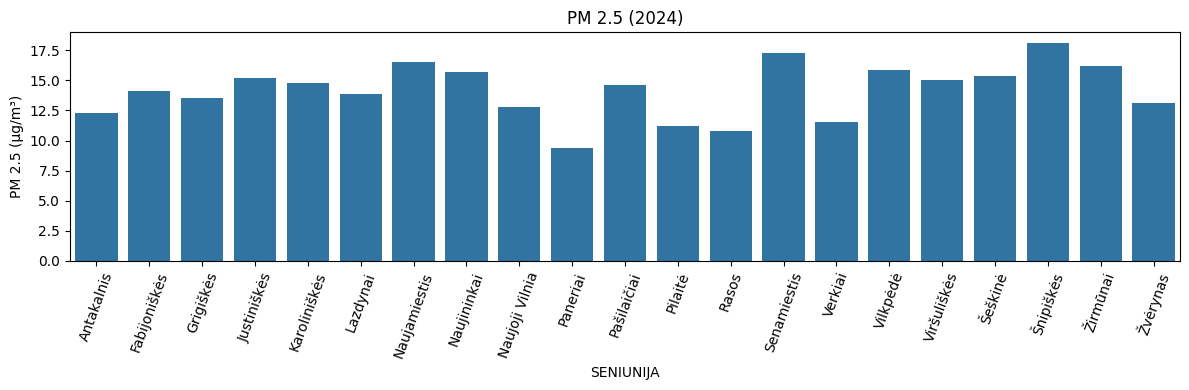

In [353]:
plt.figure(figsize=(12, 4))
sns.barplot(x="SENIUNIJA", y="PM2.5_µg_per_m3", data=df_metrics)
plt.xticks(rotation=70)
plt.ylabel("PM 2.5 (µg/m³)")
plt.title("PM 2.5 (2024)")
plt.tight_layout()
plt.show()

#### 4.3 PM2.5 and NO₂ Spatial Patterns

Horizontal bar charts compare eldership-level PM2.5 and NO₂ concentrations, with citywide means indicated for reference.

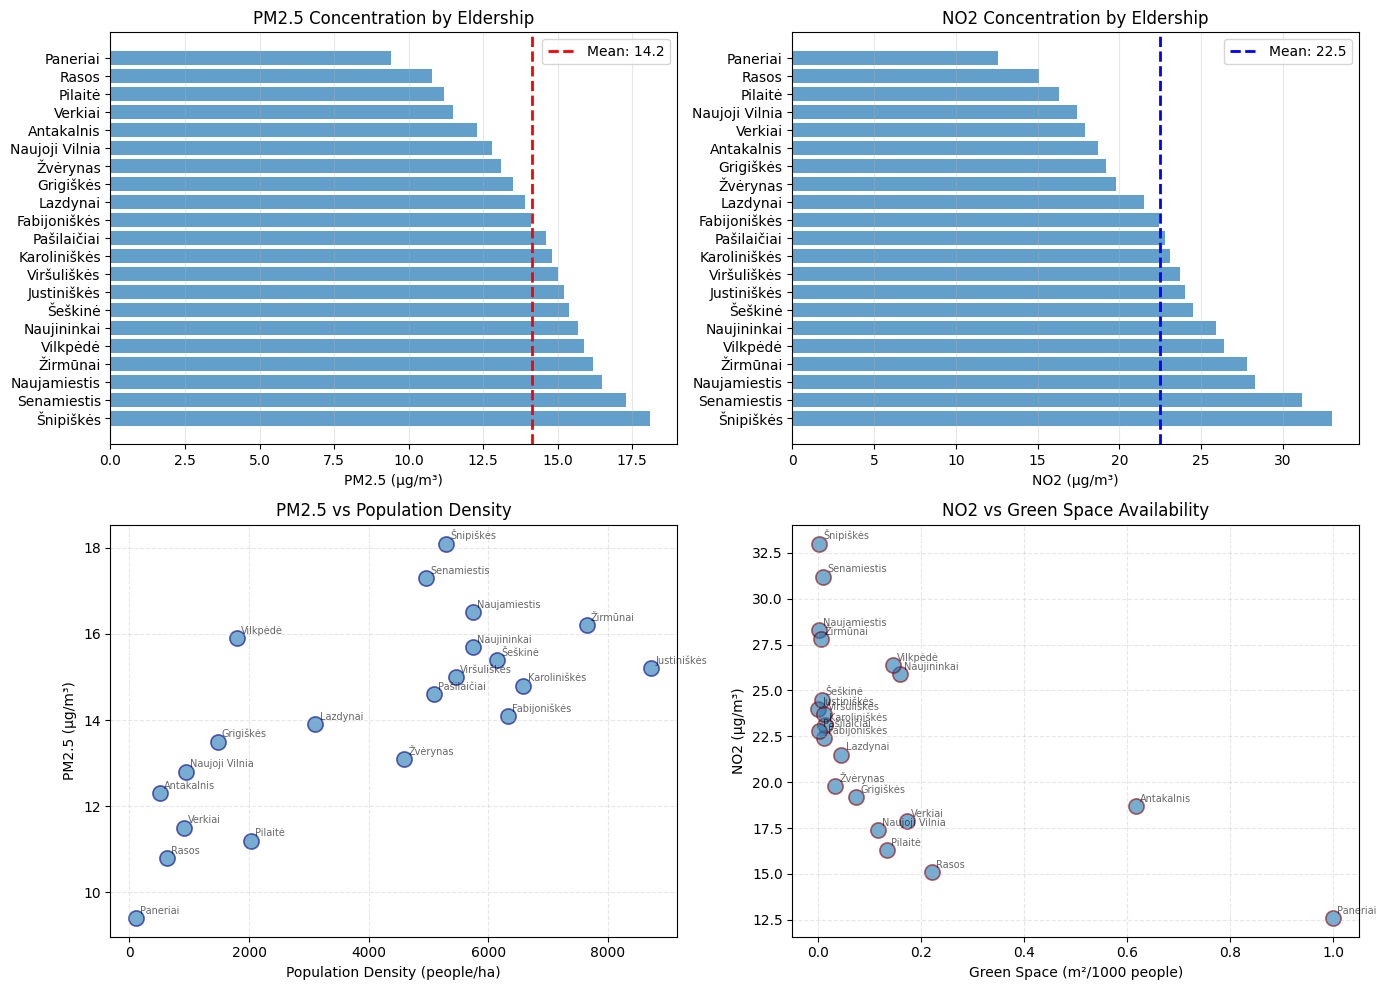

In [354]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
df_sorted_pm = df_metrics.sort_values("PM2.5_µg_per_m3", ascending=False)
ax1.barh(df_sorted_pm["SENIUNIJA"], df_sorted_pm["PM2.5_µg_per_m3"], alpha=0.7)
ax1.axvline(df_metrics["PM2.5_µg_per_m3"].mean(), color="red", linestyle="--", linewidth=2,
            label=f"Mean: {df_metrics['PM2.5_µg_per_m3'].mean():.1f}")
ax1.set_xlabel("PM2.5 (µg/m³)")
ax1.set_title("PM2.5 Concentration by Eldership")
ax1.legend()
ax1.grid(axis="x", alpha=0.3)

ax2 = axes[0, 1]
df_sorted_no2 = df_metrics.sort_values("NO2_µg_per_m3", ascending=False)
ax2.barh(df_sorted_no2["SENIUNIJA"], df_sorted_no2["NO2_µg_per_m3"], alpha=0.7)
ax2.axvline(df_metrics["NO2_µg_per_m3"].mean(), color="blue", linestyle="--", linewidth=2,
            label=f"Mean: {df_metrics['NO2_µg_per_m3'].mean():.1f}")
ax2.set_xlabel("NO2 (µg/m³)")
ax2.set_title("NO2 Concentration by Eldership")
ax2.legend()
ax2.grid(axis="x", alpha=0.3)

ax3 = axes[1, 0]
ax3.scatter(df_metrics["density"], df_metrics["PM2.5_µg_per_m3"], s=120, alpha=0.6, edgecolors="navy", linewidth=1.2)
ax3.set_xlabel("Population Density (people/ha)")
ax3.set_ylabel("PM2.5 (µg/m³)")
ax3.set_title("PM2.5 vs Population Density")
ax3.grid(True, alpha=0.3, linestyle="--")
for _, row in df_metrics.iterrows():
    ax3.annotate(row["SENIUNIJA"], (row["density"], row["PM2.5_µg_per_m3"]), fontsize=7, alpha=0.6,
                 xytext=(3, 3), textcoords="offset points")

ax4 = axes[1, 1]
ax4.scatter(df_metrics["green_area_per_1000"], df_metrics["NO2_µg_per_m3"], s=120, alpha=0.6, edgecolors="darkred", linewidth=1.2)
ax4.set_xlabel("Green Space (m²/1000 people)")
ax4.set_ylabel("NO2 (µg/m³)")
ax4.set_title("NO2 vs Green Space Availability")
ax4.grid(True, alpha=0.3, linestyle="--")
for _, row in df_metrics.iterrows():
    ax4.annotate(row["SENIUNIJA"], (row["green_area_per_1000"], row["NO2_µg_per_m3"]), fontsize=7, alpha=0.6,
                 xytext=(3, 3), textcoords="offset points")

plt.tight_layout()
plt.show()


## 5. Correlation Analysis with Statistical Significance

This section examines pairwise relationships between key quantitative indicators used in the Urban Equity Index framework. Pearson correlation coefficients are computed to assess linear associations, while statistical significance is explicitly evaluated to distinguish robust relationships from spurious correlations.

#### 5.1 Preparation of Numeric Variables

Only numeric variables are retained for correlation analysis. Columns related to time or year identifiers are excluded to avoid artificial correlations.

In [355]:
numeric_df = df_metrics.select_dtypes(include=[np.number]).copy()
numeric_df = numeric_df.loc[:, ~numeric_df.columns.str.contains("year", case=False, regex=True)]

print("\nNumeric columns included in correlation:")
print(numeric_df.columns.tolist())
print("Shape:", numeric_df.shape)


Numeric columns included in correlation:
['population', 'density', 'green_area_ha', 'health_count', 'education_count', 'culture_count', 'green_area_per_1000', 'health_per_1000', 'education_per_1000', 'culture_per_1000', '% Elderly', 'Avg Monthly Income (€)', 'Unemployment Rate (%)', 'Population_Density_people_ha', 'Dwelling_Density_dwellings_ha', 'Gross_Density_dwellings_ha_net', 'Floor_Area_Ratio_FAR', 'Green_Space_Percent', 'Household_Size_people', 'PM2.5_µg_per_m3', 'NO2_µg_per_m3', 'UEI_raw', 'vulnerability_penalty', 'UEI', 'UEI_normalized', 'employment_score', 'balanced_equity_index']
Shape: (21, 27)


#### 5.2 Pearson Correlation and Significance Testing

Pearson correlation coefficients are computed for all variable pairs. Corresponding p-values are calculated using pairwise complete observations to account for missing data.

In [356]:
corr = numeric_df.corr(method="pearson")

cols = corr.columns
pvals = pd.DataFrame(np.ones(corr.shape), columns=cols, index=cols)

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        x = numeric_df[cols[i]]
        y = numeric_df[cols[j]]
        mask = x.notna() & y.notna()
        if mask.sum() < 3 or x[mask].std() == 0 or y[mask].std() == 0:
            p = 1.0
        else:
            _, p = stats.pearsonr(x[mask], y[mask])
        pvals.iloc[i, j] = p
        pvals.iloc[j, i] = p

#### 5.3 Significance Annotation

Statistical significance is encoded using conventional star notation:

- "***" p < 0.001
- "**" p < 0.01
- "*" p < 0.05

In [357]:
def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

labels = corr.round(2).astype(str)
for i in range(len(cols)):
    for j in range(len(cols)):
        labels.iloc[i, j] = f"{corr.iloc[i, j]:.2f}{sig_stars(pvals.iloc[i, j])}"

#### 5.4 Correlation Matrix Visualization

The correlation matrix is visualized using a diverging color scale. Only the upper triangle is displayed to avoid redundancy, with correlation coefficients and significance markers annotated in each cell.

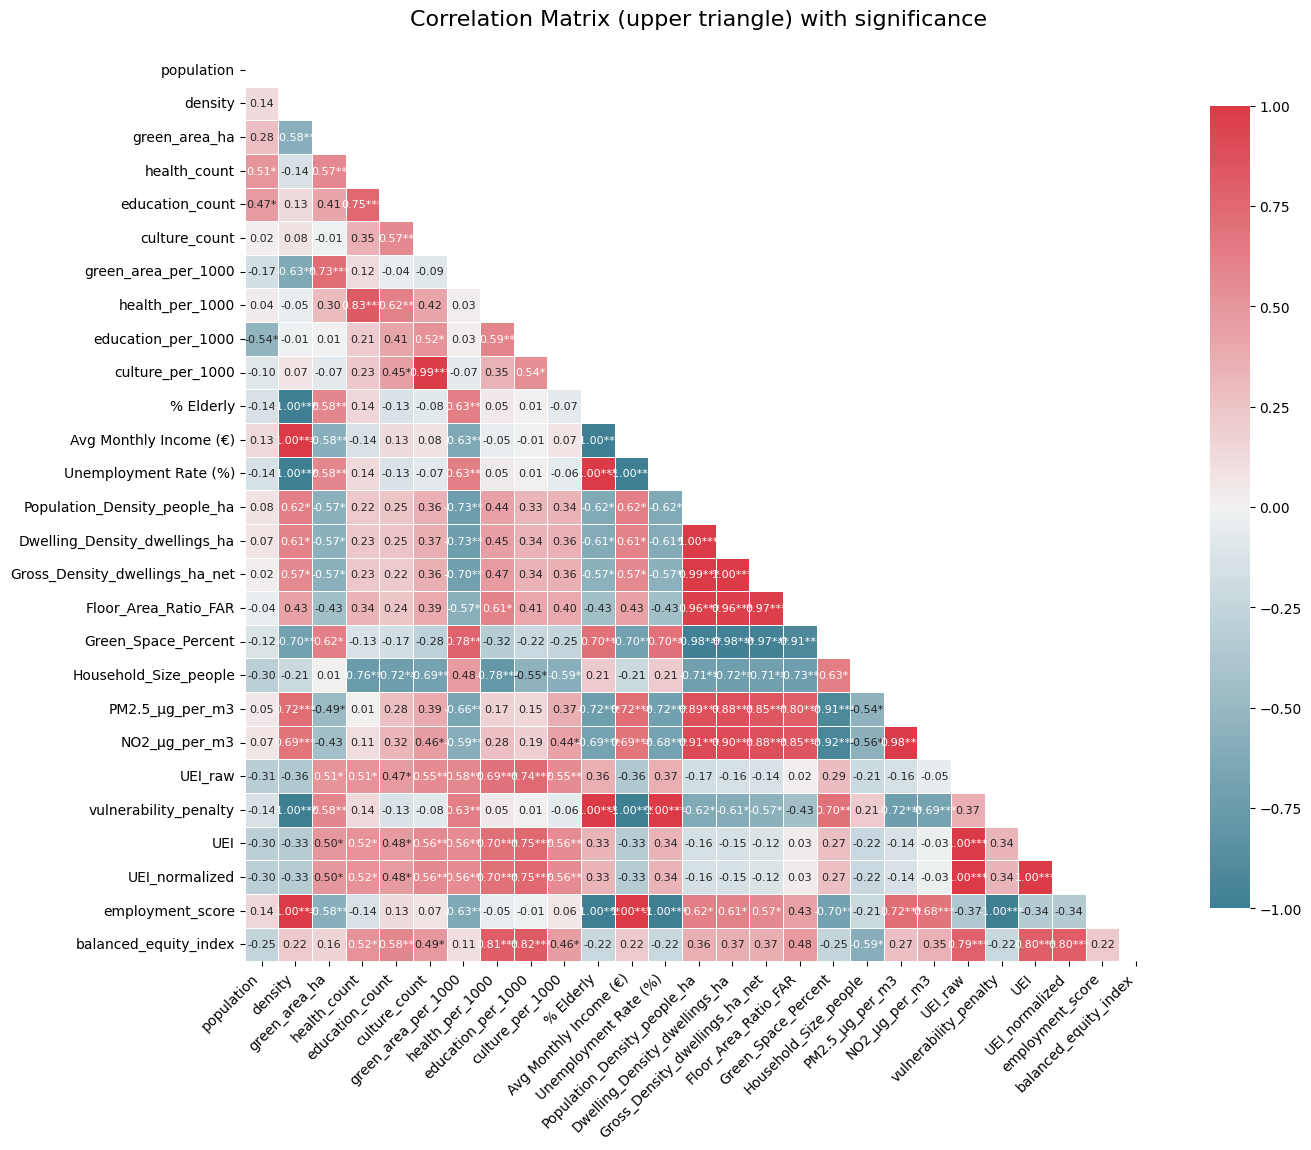

In [358]:
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(14, 12))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    corr, mask=mask, annot=labels, fmt="",
    cmap=cmap, vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
    annot_kws={"fontsize": 8}
)
plt.title("Correlation Matrix (upper triangle) with significance", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Bus Stop Data (Public Transport Accessibility)

#### 6.1 Bus Stop Data Retrieval (Live API)

Bus stop locations are obtained from the Vilnius City Municipality ArcGIS REST API. The dataset includes point geometries and descriptive attributes for all registered bus stops in the city.

All bus stop features are requested from the API using a universal query (where=1=1). Each feature’s attributes and geometry are extracted and converted into a GeoDataFrame.

In [359]:
BUS_STOPS_URL = "https://gis.vplanas.lt/arcgis/rest/services/Interaktyvus_zemelapis/Bendrasis_planas_2021/MapServer/97/query"

In [360]:
def fetch_bus_stops():
    params = {"where": "1=1", "outFields": "*", "returnGeometry": "true", "f": "pjson"}
    r = requests.get(BUS_STOPS_URL, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()

    rows = []
    for f in data.get("features", []):
        attrs = f.get("attributes", {}).copy()
        geom = f.get("geometry", {}) or {}
        x, y = geom.get("x"), geom.get("y")
        if x is None or y is None:
            continue
        attrs["geometry"] = Point(x, y)
        rows.append(attrs)

    gdf = gpd.GeoDataFrame(rows, geometry="geometry")

    sr = data.get("spatialReference", {}) or {}
    wkid = sr.get("latestWkid") or sr.get("wkid") or 3346
    gdf.set_crs(epsg=int(wkid), inplace=True)
    return gdf

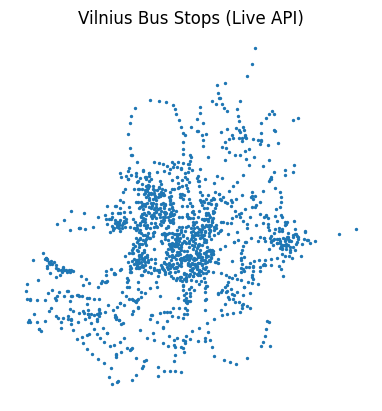

In [361]:
bus_stops = fetch_bus_stops()
bus_stops.to_crs(4326).plot(markersize=2)
plt.title("Vilnius Bus Stops (Live API)")
plt.axis("off")
plt.show()

#### 6.2 Eldership Polygons and Equity Data Integration

Eldership boundary polygons are loaded and merged with socioeconomic equity indicators. The eldership name field is standardized to ensure a consistent join key.

In [362]:
elderships = gpd.read_file(ELDERSHIPS_GEOJSON)

# name field check
if "Eldership" in elderships.columns and "SENIUNIJA" not in elderships.columns:
    elderships = elderships.rename(columns={"Eldership": "SENIUNIJA"})

Equity metrics are prepared and merged into the polygon dataset.

In [363]:
equity = df_metrics.copy()
equity = equity.rename(columns={
    "Avg Monthly Income (€)": "avg_monthly_income_eur",
    "Unemployment Rate (%)": "unemployment_rate_pct"
})

elderships = elderships.to_crs(bus_stops.crs)
elderships = elderships.merge(equity, on="SENIUNIJA", how="left", suffixes=("_poly", "_eq"))

#### 6.3 Population and Density Calculations

Population values are resolved by prioritizing equity-table data when available. Population density is then calculated using eldership area.

In [364]:
if "population_eq" in elderships.columns:
    if "population_poly" in elderships.columns:
        elderships["population"] = elderships["population_eq"].fillna(elderships["population_poly"])
    else:
        elderships["population"] = elderships["population_eq"]
elif "population" not in elderships.columns and "population_poly" in elderships.columns:
    elderships["population"] = elderships["population_poly"]


elderships["population_density"] = elderships["population"] / (elderships.geometry.area / 1_000_000)

#### 6.4 Spatial Aggregation of Bus Stops

Each bus stop is spatially assigned to an eldership using a spatial join. The intersects predicate ensures robust assignment for boundary cases.

In [365]:
stops_with_eld = gpd.sjoin(
    bus_stops,
    elderships[["SENIUNIJA", "geometry"]],
    how="left",
    predicate="intersects" 
)

The number of bus stops per eldership is then calculated.

In [366]:
stops_per_eld = stops_with_eld.groupby("SENIUNIJA").size().rename("n_stops")
elderships = elderships.merge(stops_per_eld, on="SENIUNIJA", how="left")
elderships["n_stops"] = elderships["n_stops"].fillna(0)

#### 6.5 Public Transport Accessibility Indicators

Several transport accessibility indicators are computed to capture both spatial and population-based access:

In [367]:
elderships["stops_per_km2"] = elderships["n_stops"] / (elderships.geometry.area / 1_000_000)
elderships["stops_per_1000_residents"] = elderships["n_stops"] / (elderships["population"] / 1000)
elderships["stops_per_100_residents"] = elderships["n_stops"] / elderships["population"] * 100

#### 6.6 Visualization of Transport Accessibility

Bus stop density and per-capita accessibility are visualized using bar charts and choropleth maps.

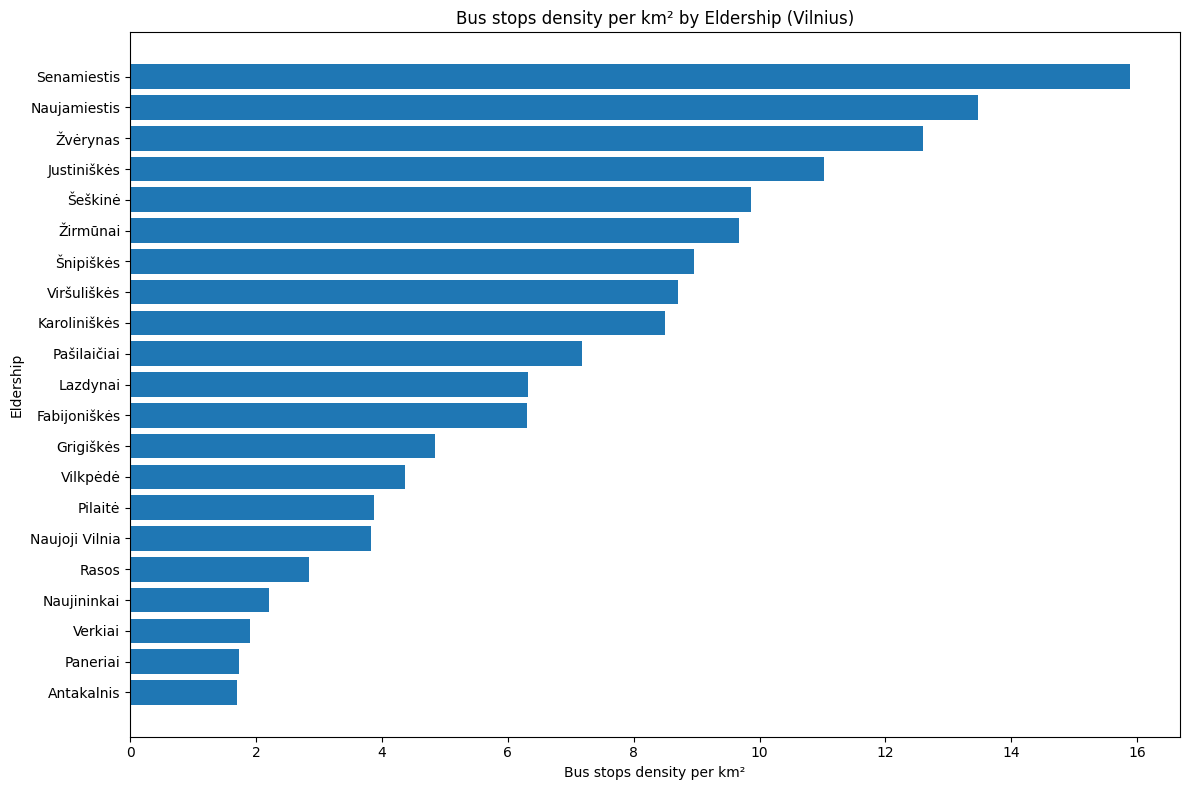

In [368]:
plot_df = elderships.sort_values("stops_per_km2")
plt.figure(figsize=(12, 8))
plt.barh(plot_df["SENIUNIJA"], plot_df["stops_per_km2"])
plt.xlabel("Bus stops density per km²")
plt.ylabel("Eldership")
plt.title("Bus stops density per km² by Eldership (Vilnius)")
plt.tight_layout()
plt.show()

Bar plots Bus stops per 100 - 1000 residents by Eldership 

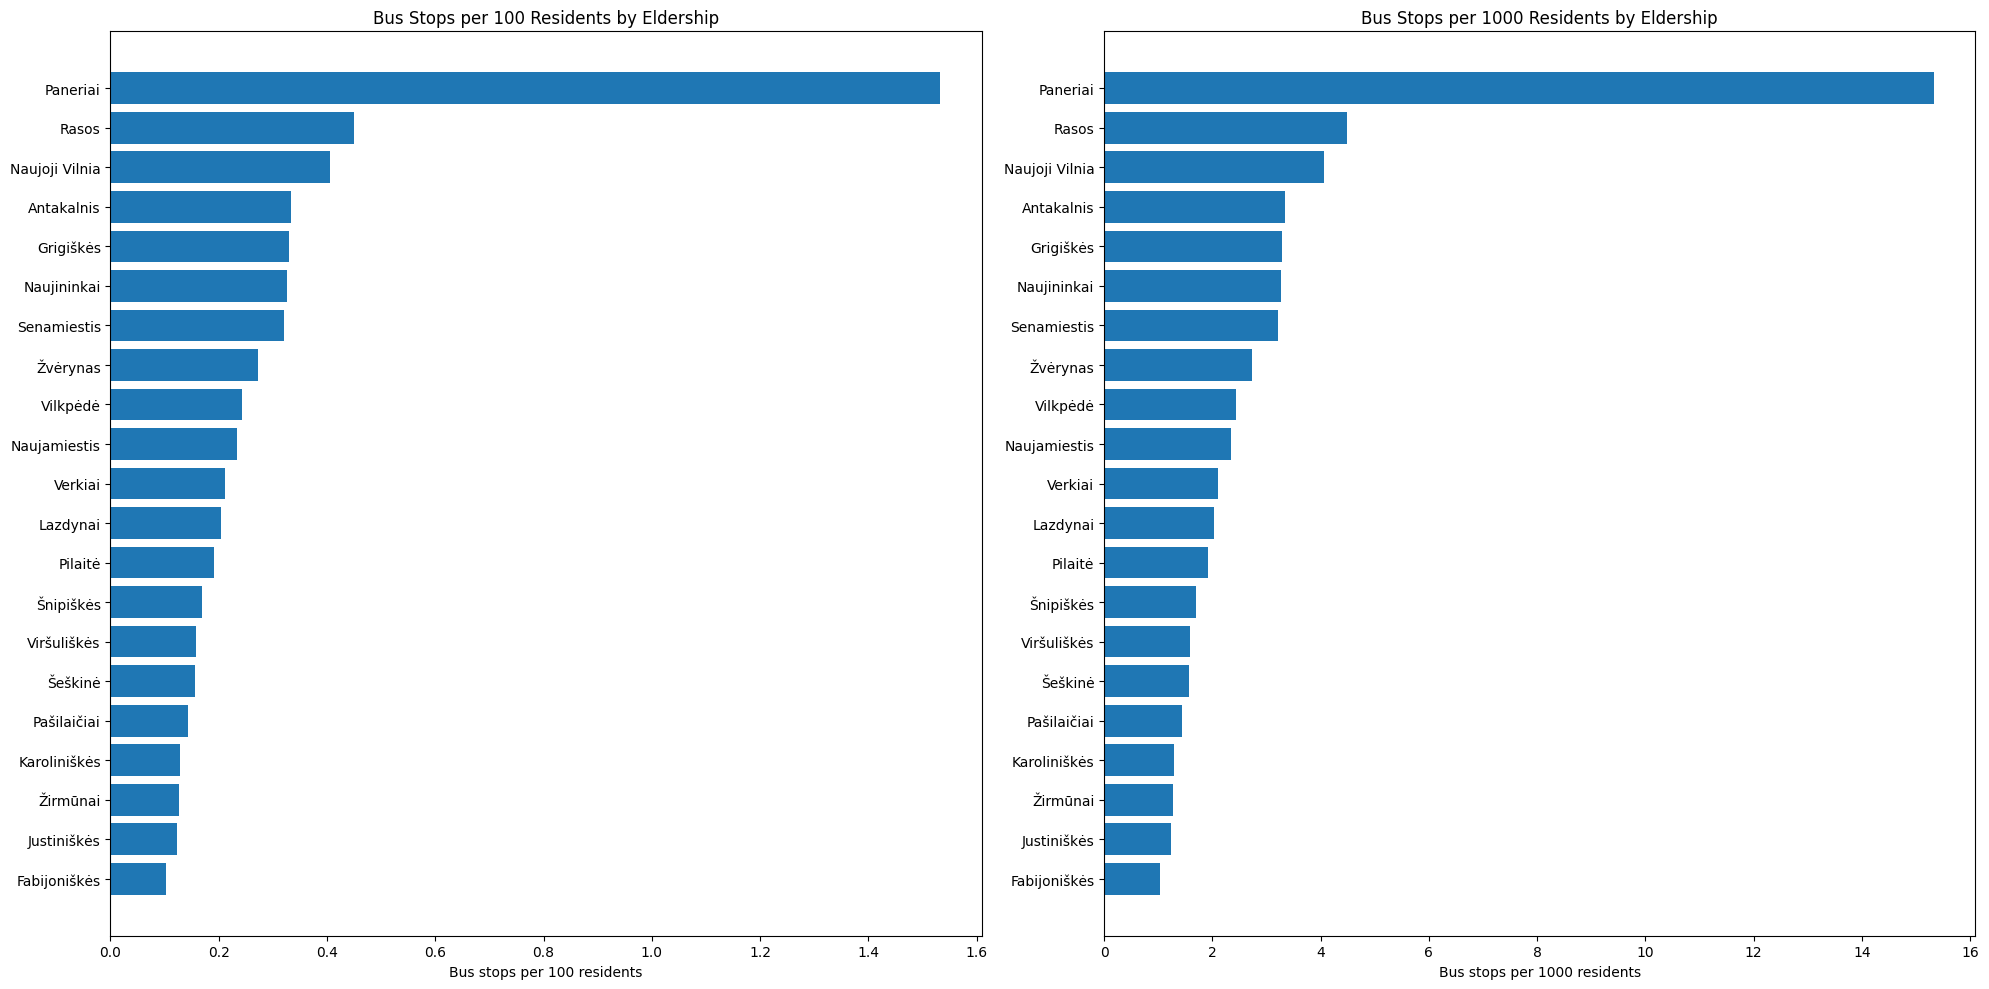

In [369]:
plot_df_100 = elderships.sort_values("stops_per_100_residents")
plot_df_1000 = elderships.sort_values("stops_per_1000_residents")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.barh(plot_df_100["SENIUNIJA"], plot_df_100["stops_per_100_residents"])
ax1.set_xlabel("Bus stops per 100 residents")
ax1.set_title("Bus Stops per 100 Residents by Eldership")

ax2.barh(plot_df_1000["SENIUNIJA"], plot_df_1000["stops_per_1000_residents"])
ax2.set_xlabel("Bus stops per 1000 residents")
ax2.set_title("Bus Stops per 1000 Residents by Eldership")
plt.tight_layout()
plt.show()

Choropleth map Bus stops per 1000 residents

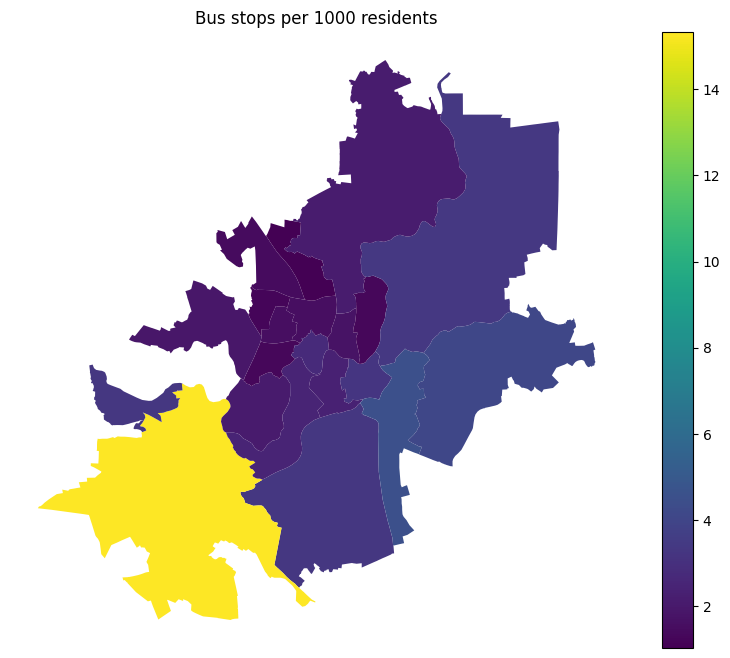

In [370]:
ax = elderships.plot(column="stops_per_1000_residents", legend=True, figsize=(10, 8))
plt.title("Bus stops per 1000 residents")
plt.axis("off")
plt.show()

Density per km² -> shows the central districts are best served.

Stops per resident -> shows low-density outer districts appear “well-served,” but mainly due to small population, not true accessibility.

Thus:

- City center = best physical stop coverage
- Outer districts = high stops per resident but low density
- Northwestern high-population districts = lowest accessibility by both metrics (real mobility gap)

#### 6.7 Relationship Between Transport and Green Space

The relationship between public transport accessibility and green space availability is examined using a scatter plot and linear trend.

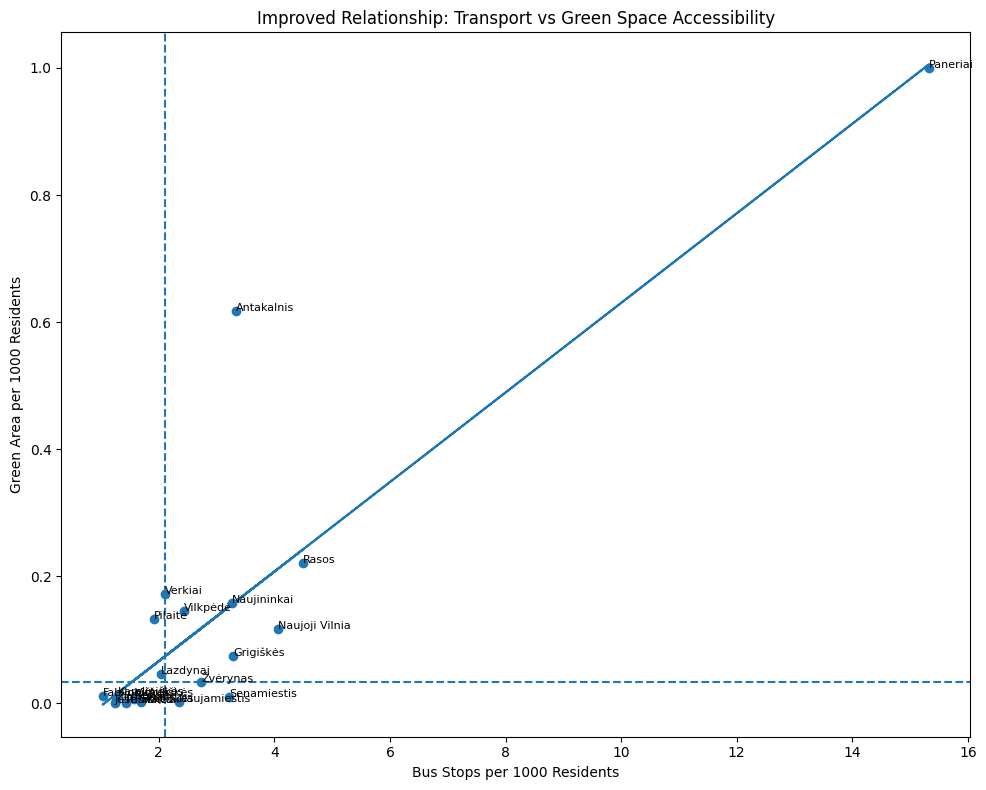

In [371]:
# Relationship Chart: Green Space vs Transport Access
green_col = "green_area_per_1000_eq" if "green_area_per_1000_eq" in elderships.columns else "green_area_per_1000"
x = elderships["stops_per_1000_residents"]
y = elderships[green_col]

plt.figure(figsize=(10, 8))
plt.scatter(x, y)

# Regression line (avoid polyfit crash if too few points)
mask_xy = x.notna() & y.notna()
if mask_xy.sum() >= 2:
    m, b = np.polyfit(x[mask_xy], y[mask_xy], 1)
    plt.plot(x[mask_xy], m * x[mask_xy] + b)

plt.axvline(x.median(), linestyle="--")
plt.axhline(y.median(), linestyle="--")
plt.xlabel("Bus Stops per 1000 Residents")
plt.ylabel("Green Area per 1000 Residents")
plt.title("Improved Relationship: Transport vs Green Space Accessibility")

for _, row in elderships.iterrows():
    if pd.notna(row["stops_per_1000_residents"]) and pd.notna(row[green_col]):
        plt.text(row["stops_per_1000_residents"], row[green_col], row["SENIUNIJA"], fontsize=8)

plt.tight_layout()
plt.show()


- Upper-right quadrant (high transport, high green space):
Elderships such as Paneriai and Antakalnis perform well on both dimensions, indicating strong overall accessibility and favorable living conditions.

- Lower-right quadrant (high transport, low green space):
Some centrally located or densely built areas show good public transport coverage but limited green space, reflecting urban density and land-use constraints.

- Upper-left quadrant (low transport, high green space):
These areas enjoy environmental advantages but may suffer from weaker public transport connections, potentially increasing car dependency.

- Lower-left quadrant (low transport, low green space):
Elderships in this quadrant face compound accessibility disadvantages, lacking both adequate transport access and green space availability.

Analytical Implications

This analysis highlights that transport accessibility and environmental amenities do not always trade off against each other, but neither are they perfectly aligned. The observed variability justifies the construction of a combined accessibility score in the following section, as relying on a single indicator would fail to capture multidimensional urban equity.

#### 6.8 Combined Accessibility Score

A combined accessibility score is constructed by equally weighting normalized transport and green space indicators.

In [372]:
# Combined accessibility score (your block)
scaler = MinMaxScaler()
elderships["transport_norm"] = scaler.fit_transform(elderships[["stops_per_1000_residents"]])
elderships["green_norm"] = scaler.fit_transform(elderships[[green_col]])

elderships["accessibility_score"] = 0.5 * elderships["transport_norm"] + 0.5 * elderships["green_norm"]

ranking = elderships[["SENIUNIJA", "accessibility_score"]].sort_values("accessibility_score", ascending=False)
print("\nTop 5 Elderships (Best Combined Accessibility):")
print(ranking.head().to_string(index=False))
print("\nBottom 5 Elderships (Lowest Combined Accessibility):")
print(ranking.tail().to_string(index=False))



Top 5 Elderships (Best Combined Accessibility):
     SENIUNIJA  accessibility_score
      Paneriai             1.000000
    Antakalnis             0.389115
         Rasos             0.231795
Naujoji Vilnia             0.164034
   Naujininkai             0.157299

Bottom 5 Elderships (Lowest Combined Accessibility):
   SENIUNIJA  accessibility_score
Karoliniškės             0.016042
 Pašilaičiai             0.014754
    Žirmūnai             0.011011
 Justiniškės             0.007202
Fabijoniškės             0.005250


Map of Combined Score

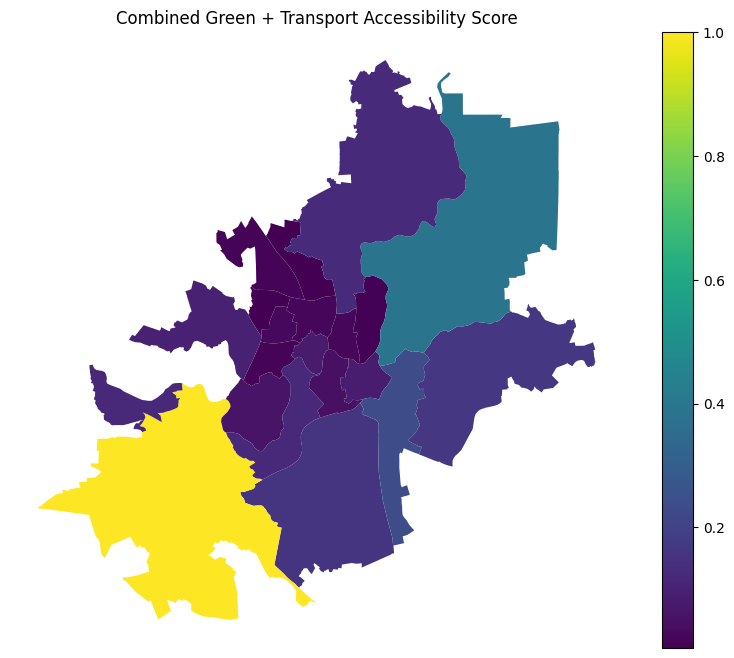

In [373]:

ax = elderships.plot(column="accessibility_score", legend=True, figsize=(10, 8))
plt.title("Combined Green + Transport Accessibility Score")
plt.axis("off")
plt.show()

## 7. Transport and Social Vulnerability Index (TSVI)

This section introduces the Transport and Social Vulnerability Index (TSVI), a composite indicator designed to identify elderships where high social vulnerability coincides with poor public transport accessibility. The index integrates demographic, socioeconomic, and transport-related variables into a single, interpretable metric.

#### 7.1 Social Vulnerability Components

Social vulnerability is operationalized using three indicators:

- Share of elderly population – representing age-related mobility and care needs
- Unemployment rate – reflecting economic vulnerability
- Average monthly income – capturing material resources and resilience

To ensure robustness after dataset merging, column names are selected dynamically depending on suffix availability.

In [374]:
# choose correct columns after merge
unemp_col = "unemployment_rate_pct" if "unemployment_rate_pct" in elderships.columns else "unemployment_rate_pct_eq"
income_col = "avg_monthly_income_eur" if "avg_monthly_income_eur" in elderships.columns else "avg_monthly_income_eur_eq"
elderly_col = "% Elderly" if "% Elderly" in elderships.columns else "% Elderly_eq"


#### 7.2 Normalization of Vulnerability Indicators

All indicators are normalized using Min–Max scaling to ensure comparability on a common [0,1] scale.

- Higher values indicate greater vulnerability
- Income is inverted, as higher income implies lower vulnerability

In [375]:

scaler = MinMaxScaler()
elderships["elderly_norm"] = scaler.fit_transform(elderships[[elderly_col]])
elderships["unemployment_norm"] = scaler.fit_transform(elderships[[unemp_col]])

elderships["income_norm"] = scaler.fit_transform(elderships[[income_col]])
elderships["income_norm_inverted"] = 1 - elderships["income_norm"]


#### 7.3 Social Vulnerability Score Construction

The Social Vulnerability Score (SVS) is computed as a weighted linear combination of normalized indicators:
- Elderly population: 40%
- Unemployment rate: 30%
- Inverted income: 30%

In [376]:

elderships["social_vulnerability_score"] = (
    0.40 * elderships["elderly_norm"] +
    0.30 * elderships["unemployment_norm"] +
    0.30 * elderships["income_norm_inverted"]
)

This weighting emphasizes age-related vulnerability while maintaining balance with economic factors.

#### 7.4 Transport Need Indicator

Transport accessibility is transformed into a transport need measure by inverting normalized bus stop availability. Areas with fewer bus stops per capita therefore receive higher transport-need scores.

In [377]:

elderships["transport_norm"] = scaler.fit_transform(elderships[["stops_per_1000_residents"]])
elderships["transport_need"] = 1 - elderships["transport_norm"]


#### 7.5 TSVI Construction

The final Transport and Social Vulnerability Index (TSVI) combines social vulnerability and transport need:
- Social vulnerability: 60%
- Transport need: 40%

In [378]:

elderships["TSVI"] = 0.6 * elderships["social_vulnerability_score"] + 0.4 * elderships["transport_need"]

This formulation prioritizes socially vulnerable populations while explicitly accounting for deficiencies in public transport access.

#### 7.6 Ranking and Spatial Distribution

Elderships are ranked by TSVI to identify priority areas for intervention.

In [379]:

tsvi_rank = elderships[["SENIUNIJA", "TSVI"]].sort_values("TSVI", ascending=False)
print("\nTop 5 Highest Vulnerability + Poor Transport (Priority Areas):")
print(tsvi_rank.head().to_string(index=False))
print("\nBottom 5 (Lowest Vulnerability, Good Transport):")
print(tsvi_rank.tail().to_string(index=False))



Top 5 Highest Vulnerability + Poor Transport (Priority Areas):
     SENIUNIJA     TSVI
       Verkiai 0.913599
    Antakalnis 0.906074
         Rasos 0.868770
Naujoji Vilnia 0.856052
     Grigiškės 0.842878

Bottom 5 (Lowest Vulnerability, Good Transport):
   SENIUNIJA     TSVI
     Šeškinė 0.564623
 Naujininkai 0.546727
Karoliniškės 0.542200
    Žirmūnai 0.469699
 Justiniškės 0.394239


- Highest TSVI values indicate areas with both high vulnerability and poor transport access
- Lowest TSVI values represent socially resilient areas with good transport coverage

A choropleth map visualizes the spatial distribution of TSVI across Vilnius.

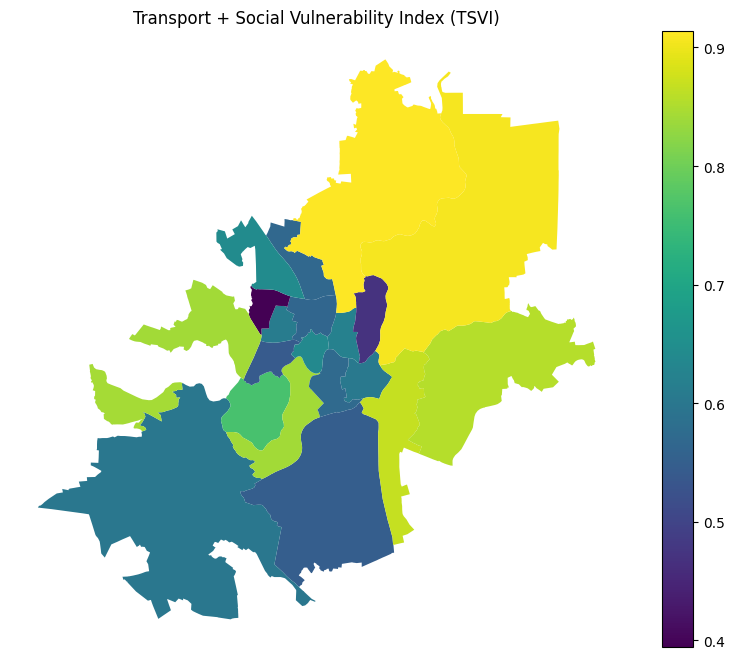

In [380]:
ax = elderships.plot(column="TSVI", legend=True, figsize=(10, 8))
plt.title("Transport + Social Vulnerability Index (TSVI)")
plt.axis("off")
plt.show()


#### 7.7 Relationship Between Social Vulnerability and Transport Need

To explore interactions between the two TSVI components, a scatter plot compares social vulnerability scores with transport need.

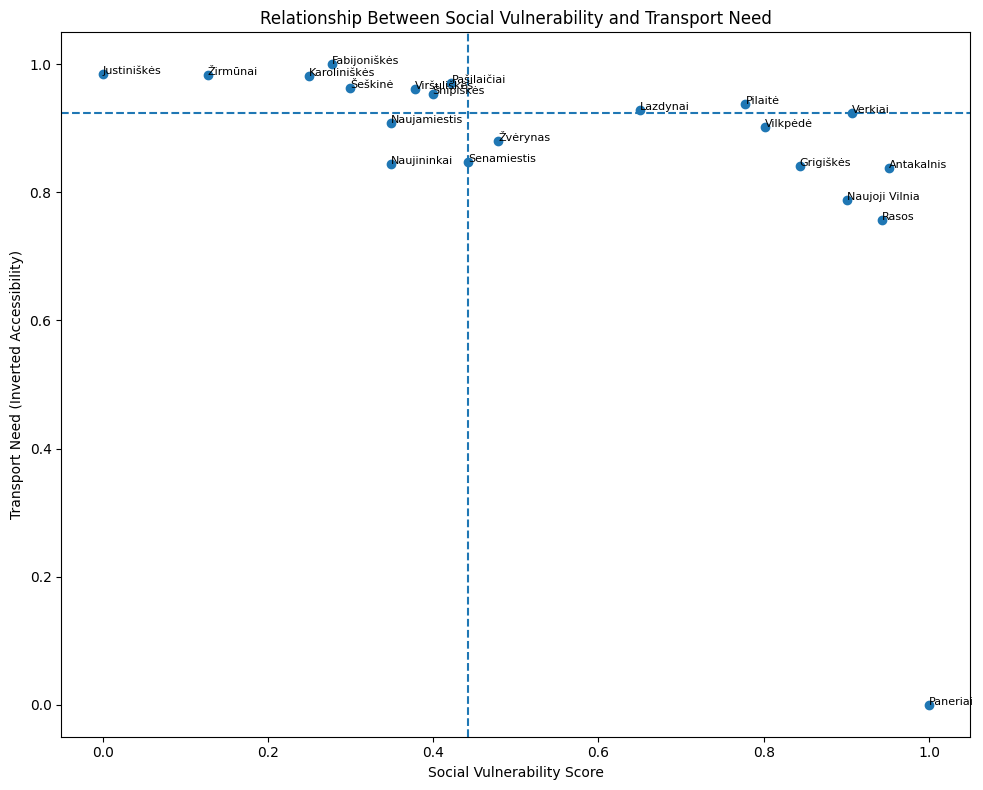

In [381]:
plt.figure(figsize=(10, 8))
plt.scatter(elderships["social_vulnerability_score"], elderships["transport_need"])
plt.xlabel("Social Vulnerability Score")
plt.ylabel("Transport Need (Inverted Accessibility)")
plt.title("Relationship Between Social Vulnerability and Transport Need")

for _, row in elderships.iterrows():
    plt.text(row["social_vulnerability_score"], row["transport_need"], row["SENIUNIJA"], fontsize=8)

plt.axvline(elderships["social_vulnerability_score"].median(), linestyle="--")
plt.axhline(elderships["transport_need"].median(), linestyle="--")
plt.tight_layout()
plt.show()

- Top-right quadrant (high vulnerability, high transport need):
These elderships are the most disadvantaged. Residents are socially vulnerable and also have poor access to public transport. These areas should be highest priority for transport improvements.

- Top-left quadrant (low vulnerability, high transport need):
Transport access is weak, but social conditions are relatively better. Improvements here would mainly support mobility and sustainability.

- Bottom-right quadrant (high vulnerability, low transport need):
Social vulnerability is high, but transport access is good. Public transport may already be helping reduce inequality in these areas.

- Bottom-left quadrant (low vulnerability, low transport need):
These elderships are doing well on both dimensions and face the fewest accessibility problems.

## 8. Waste Container Accessibility

This section evaluates the spatial accessibility and distribution of municipal waste containers across Vilnius elderships. Waste infrastructure is a critical but often overlooked component of urban equity, influencing environmental quality, public health, and everyday livability.

#### 8.1 Data Preparation and Coordinate Reference System

In [382]:
# Load waste containers
containers = gpd.read_file(WASTE_CONTAINERS_GEOJSON).to_crs(3857)
elderships_waste = elderships.to_crs(3857).copy()

# Geometry safety
containers = containers.dropna(subset=["geometry"])
containers = containers[containers.geometry.is_valid]

elderships_waste = elderships_waste.dropna(subset=["geometry"])
elderships_waste = elderships_waste[elderships_waste.geometry.is_valid]


#### 8.2 Spatial Distribution of Waste Containers

An initial map is produced to visually inspect the spatial distribution of waste containers relative to eldership boundaries.

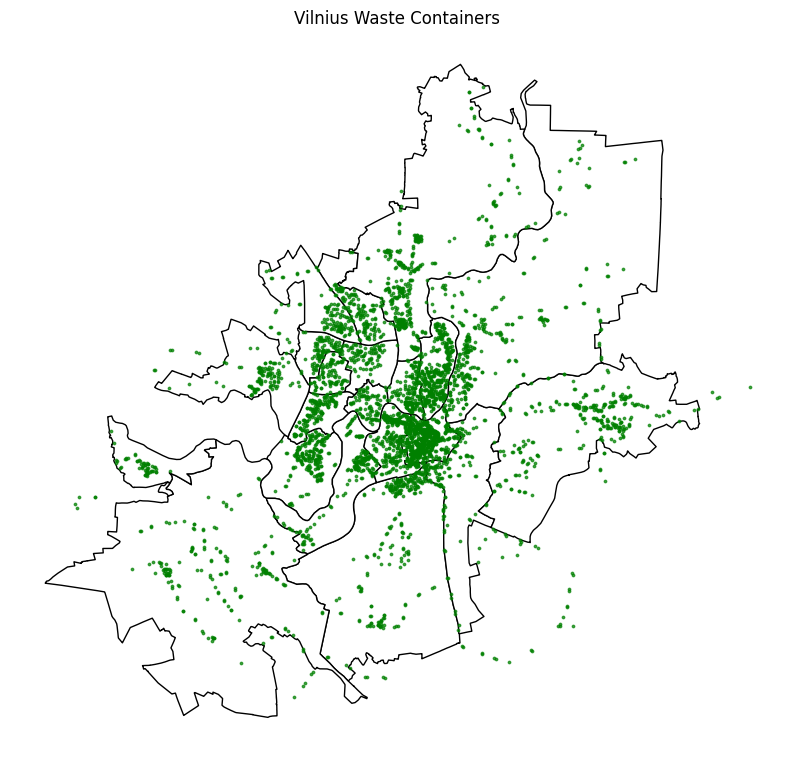

In [383]:
# Visual sanity check
base = elderships_waste.plot(figsize=(10, 10), color="white", edgecolor="black")
containers.plot(ax=base, markersize=3, color="green", alpha=0.7)
plt.title("Vilnius Waste Containers")
plt.axis("off")
plt.show()


#### 8.3 Spatial Assignment to Elderships

Each waste container is assigned to an eldership using a point-in-polygon spatial join. The within predicate ensures robust allocation of containers to administrative areas.

In [384]:

containers_joined = gpd.sjoin(
    containers,
    elderships_waste[["SENIUNIJA", "geometry"]],
    how="left",
    predicate="within"
)


#### 8.4 Waste Container Counts and Density

Waste containers are aggregated at the eldership level and normalized by area to produce a container density indicator (containers per km²).

In [385]:

count_df = (
    containers_joined
    .groupby("SENIUNIJA_right")   # ← IMPORTANT
    .size()
    .reset_index(name="container_count")
    .rename(columns={"SENIUNIJA_right": "SENIUNIJA"})
)

# Merge counts back to polygons
elderships_waste = elderships_waste.merge(
    count_df,
    on="SENIUNIJA",
    how="left"
)

elderships_waste["container_count"] = elderships_waste["container_count"].fillna(0)


#### 8.5 Service Spacing: Nearest-Neighbor Analysis

To evaluate the regularity of waste service provision, nearest-neighbor distances between containers are computed using a BallTree spatial index.

In [386]:

coords = np.vstack([
    containers.geometry.x,
    containers.geometry.y
]).T

tree = BallTree(coords, metric="euclidean")
dist, _ = tree.query(coords, k=2)

nearest_neighbor_dist = dist[:, 1]
print("\nMean nearest neighbor distance (m):", nearest_neighbor_dist.mean())
print("Median nearest neighbor distance (m):", np.median(nearest_neighbor_dist))



Mean nearest neighbor distance (m): 101.63884451871799
Median nearest neighbor distance (m): 63.480388692252376


Nearest-neighbor analysis interpretation

- The mean nearest-neighbor distance (~102 m) indicates the average spacing between waste containers across Vilnius, reflecting overall service dispersion.
- The median distance (~63 m) is substantially lower, showing that most containers are relatively closely spaced, while a smaller number of containers in sparsely served areas increase the average.

Implication:
Waste container coverage is generally dense in many neighborhoods, but unevenly distributed. A minority of areas with larger gaps between containers likely represent local accessibility deficits, suggesting targets for infrastructure infill rather than citywide expansion.

#### 8.6 Kernel Density Estimation of Container Coverage

Kernel Density Estimation (KDE) is applied to visualize continuous patterns of waste container concentration and identify service hotspots and gaps.

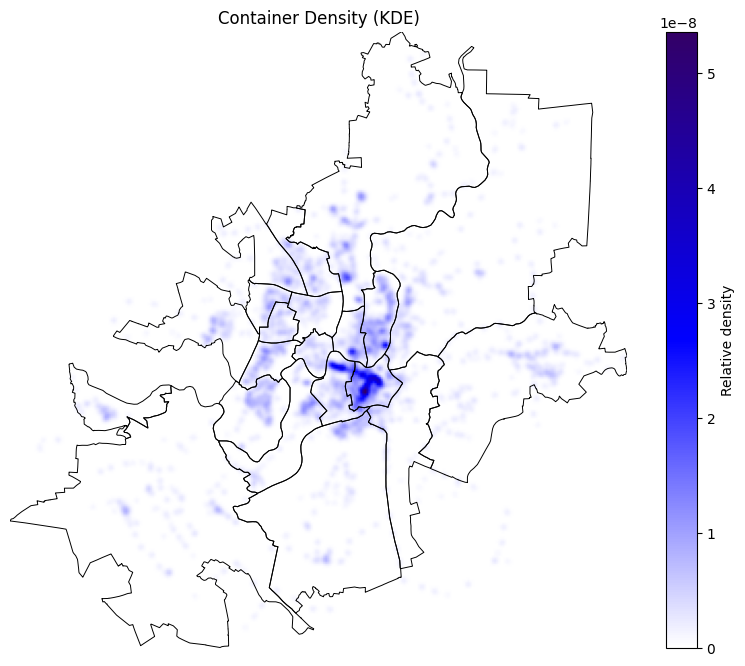

In [387]:

kde = KernelDensity(bandwidth=200).fit(coords)

xmin, ymin, xmax, ymax = elderships_waste.total_bounds
xgrid = np.linspace(xmin, xmax, 300)
ygrid = np.linspace(ymin, ymax, 300)
xx, yy = np.meshgrid(xgrid, ygrid)
grid_coords = np.vstack([xx.ravel(), yy.ravel()]).T

z = np.exp(kde.score_samples(grid_coords)).reshape(xx.shape)

cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_to_blue_to_purple",
    [(1, 1, 1), (0, 0, 1), (0.2, 0, 0.4)],
    N=256
)

plt.figure(figsize=(10, 8))
plt.imshow(z, extent=[xmin, xmax, ymin, ymax], origin="lower", cmap=cmap)
elderships_waste.boundary.plot(ax=plt.gca(), linewidth=0.7, edgecolor="black")
plt.title("Container Density (KDE)")
plt.axis("off")
plt.colorbar(label="Relative density")
plt.show()


#### 8.7 Clustering of Waste Infrastructure

K-means clustering is applied to explore spatial groupings of waste containers and identify areas of concentrated infrastructure.

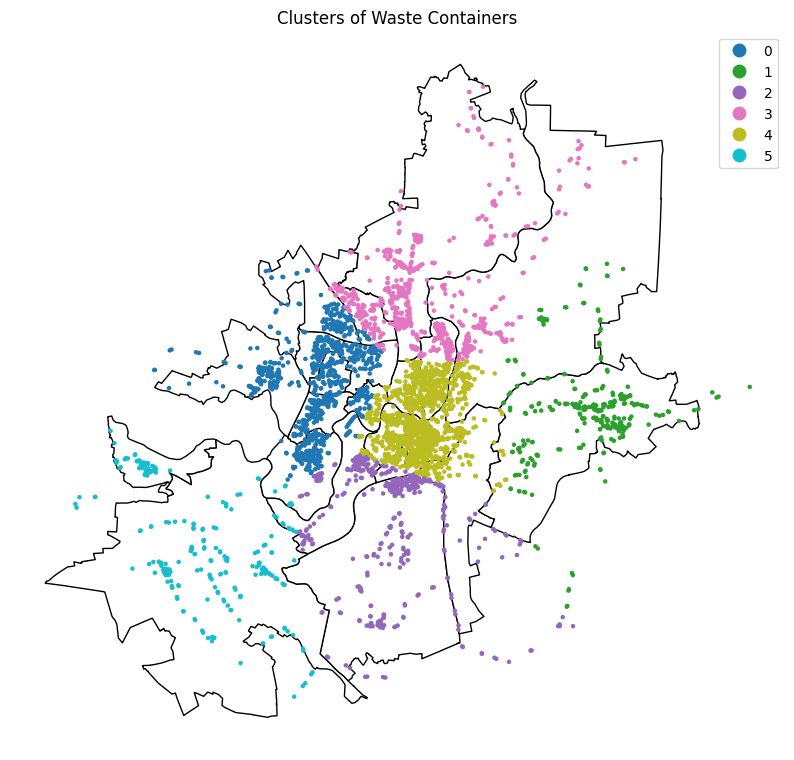

In [388]:

kmeans_cont = KMeans(n_clusters=6, random_state=42, n_init="auto")
containers["cluster"] = kmeans_cont.fit_predict(coords)

ax = elderships_waste.plot(figsize=(10, 10), color="white", edgecolor="black")
containers.plot(ax=ax, column="cluster", categorical=True, legend=True, markersize=5)
plt.title("Clusters of Waste Containers")
plt.axis("off")
plt.show()


#### 8.8 Waste Accessibility Score

A composite Waste Accessibility Score is constructed to reflect both infrastructure availability and demographic sensitivity. Container density is weighted positively, while areas with higher elderly population shares receive a penalty to reflect increased accessibility needs.

In [389]:

elderships_waste["area_m2"] = elderships_waste.geometry.area
elderships_waste["area_km2"] = elderships_waste["area_m2"] / 1e6

elderships_waste["containers_per_km2"] = (
    elderships_waste["container_count"] / elderships_waste["area_km2"]
)

elderly_col = "% Elderly" if "% Elderly" in elderships_waste.columns else "% Elderly_eq"

if elderly_col in elderships_waste.columns:
    elderships_waste["waste_accessibility_score"] = (
        elderships_waste["containers_per_km2"] * 0.6 +
        elderships_waste["population"] * 0.2 -
        elderships_waste[elderly_col] * 0.2
    )
else:
    elderships_waste["waste_accessibility_score"] = (
        elderships_waste["containers_per_km2"] * 0.7 +
        elderships_waste["population"] * 0.3
    )

print("\nWaste accessibility preview:")
print(
    elderships_waste[
        ["SENIUNIJA", "container_count", "containers_per_km2", "waste_accessibility_score"]
    ].head().to_string(index=False)
)



Waste accessibility preview:
  SENIUNIJA  container_count  containers_per_km2  waste_accessibility_score
Naujininkai              258            1.957811                6002.074687
   Paneriai              165            0.709230                1755.425538
   Lazdynai              204            6.866666                6187.420000
  Grigiškės               54            2.581042                2062.668625
   Vilkpėdė              171            5.334016                3862.200410


Waste accessibility results interpretation
- Lazdynai and Naujininkai achieve the highest waste accessibility scores, driven by a high density of containers per km² combined with substantial population coverage. This indicates strong everyday service availability.
- Vilkpėdė also performs well, reflecting dense infrastructure despite a smaller total container count than Naujininkai.
- Grigiškės and Paneriai show moderate to low accessibility, primarily due to lower container density, suggesting comparatively weaker spatial coverage.

## 9. Integration of Waste Infrastructure and Final Urban Equity Index (UEI)

This section integrates waste infrastructure accessibility metrics into the main eldership dataset and constructs the final Urban Equity Index (UEI). The index combines environmental amenities, service provision, socioeconomic protection, and environmental–social burdens into a single, interpretable composite score.

#### 9.1 Merging Waste Metrics into Eldership Dataset

In [390]:
waste_merge_cols = [
    "SENIUNIJA",
    "containers_per_km2",
    "container_count"
]

elderships = elderships.merge(
    elderships_waste[waste_merge_cols],
    on="SENIUNIJA",
    how="left"
)

elderships["containers_per_km2"] = elderships["containers_per_km2"].fillna(0)
elderships["container_count"] = elderships["container_count"].fillna(0)


#### 9.2 Final UEI Metric Construction

A working copy of the enriched eldership dataset is created for UEI computation.

In [391]:
uei = elderships.copy()


A helper function is defined to apply Min–Max normalization while safely handling edge cases where variables have no variation.

In [392]:
def minmax(series):
    if series.max() == series.min():
        return pd.Series(0, index=series.index)
    return (series - series.min()) / (series.max() - series.min())


#### 9.3 Suffix-Safe Indicator Resolution

To ensure robustness after dataset merges, column names are resolved dynamically depending on whether suffixes are present.

In [393]:
green = "green_area_per_1000_eq" if "green_area_per_1000_eq" in uei.columns else "green_area_per_1000"
health = "health_per_1000_eq" if "health_per_1000_eq" in uei.columns else "health_per_1000"
edu = "education_per_1000_eq" if "education_per_1000_eq" in uei.columns else "education_per_1000"
culture = "culture_per_1000_eq" if "culture_per_1000_eq" in uei.columns else "culture_per_1000"

income = "avg_monthly_income_eur" if "avg_monthly_income_eur" in uei.columns else "avg_monthly_income_eur_eq"
unemp = "unemployment_rate_pct" if "unemployment_rate_pct" in uei.columns else "unemployment_rate_pct_eq"
elderly = "% Elderly" if "% Elderly" in uei.columns else "% Elderly_eq"

pm25 = "PM2.5_µg_per_m3"
no2 = "NO2_µg_per_m3"

transport = "stops_per_1000_residents"
waste = "containers_per_km2"
density = "population_density"


#### 9.4 Amenity Access Score

The access score captures access to core urban amenities, with a higher weight assigned to green space.

In [394]:

uei["access_score"] = (
    minmax(uei[green]) * 0.30 +
    minmax(uei[health]) * 0.25 +
    minmax(uei[edu]) * 0.25 +
    minmax(uei[culture]) * 0.20
)


#### 9.5 Service Equity Score (Transport + Waste)

Service equity combines public transport accessibility and waste infrastructure coverage.

In [395]:
uei["service_score"] = (
    minmax(uei[transport]) * 0.6 +
    minmax(uei[waste]) * 0.4
)


#### 9.6 Socioeconomic Protection Score

This component reflects economic resilience, rewarding higher incomes and lower unemployment.

In [396]:
uei["protection_score"] = (
    minmax(uei[income]) * 0.6 +
    (1 - minmax(uei[unemp])) * 0.4
)


#### 9.7 Environmental and Social Burden Score

Environmental exposure and social vulnerability are combined into a burden score, which is subsequently inverted so that higher values indicate better conditions.

In [397]:
uei["burden_score"] = (
    minmax(uei[pm25]) * 0.25 +
    minmax(uei[no2]) * 0.25 +
    minmax(uei[elderly]) * 0.20 +
    minmax(uei[unemp]) * 0.15 +
    minmax(uei[density]) * 0.15
)

uei["burden_inverted"] = 1 - uei["burden_score"]


#### 9.8 Final Urban Equity Index (UEI)

The final UEI is computed as a weighted combination of all component scores and normalized to a [0,1] scale.

In [398]:
uei["UEI_full"] = (
    uei["access_score"] * 0.35 +
    uei["service_score"] * 0.25 +
    uei["protection_score"] * 0.20 +
    uei["burden_inverted"] * 0.20
)

uei["UEI_full"] = minmax(uei["UEI_full"])


#### 9.9 Ranking and Visualization

Elderships are ranked according to the final UEI, and results are exported for further analysis and visualization.

In [399]:
uei_rank = (
    uei[["SENIUNIJA", "UEI_full"]]
    .sort_values("UEI_full", ascending=False)
)

uei_rank.to_csv(OUT_DIR / "UEI_full_ranking.csv", index=False)

print("\nTop 5 Elderships — FULL UEI:")
print(uei_rank.head().to_string(index=False))

print("\nBottom 5 Elderships — FULL UEI:")
print(uei_rank.tail().to_string(index=False))


Top 5 Elderships — FULL UEI:
   SENIUNIJA  UEI_full
 Senamiestis  1.000000
Naujamiestis  0.866387
    Paneriai  0.800578
    Žvėrynas  0.684479
 Justiniškės  0.611114

Bottom 5 Elderships — FULL UEI:
     SENIUNIJA  UEI_full
   Pašilaičiai  0.172038
       Verkiai  0.120206
     Grigiškės  0.083202
Naujoji Vilnia  0.049393
      Vilkpėdė  0.000000


Final UEI ranking interpretation
- Senamiestis ranks highest, reflecting exceptional overall urban equity driven by strong amenity access, dense service provision, and favorable socioeconomic conditions.
- Naujamiestis and Žvėrynas also perform strongly, combining high accessibility to services and green space with relatively low environmental and social burdens.
- Paneriai stands out as a high-performing non-central eldership, indicating that strong equity outcomes are not limited to the historic core.

In contrast:
- Vilkpėdė and Naujoji Vilnia rank lowest, indicating compound disadvantage across multiple dimensions, including weaker service equity and higher environmental or social burdens.
- Grigiškės and Verkiai also exhibit low UEI scores, suggesting structural gaps in accessibility that persist despite geographic or environmental advantages.

Overall implication:

The final UEI reveals a clear spatial inequality gradient across Vilnius. While central and well-connected districts dominate the top of the ranking, several peripheral or historically industrial areas emerge as priority zones for targeted urban interventions, particularly in transport, waste services, and environmental quality.

A choropleth map illustrates the spatial distribution of urban equity across Vilnius.

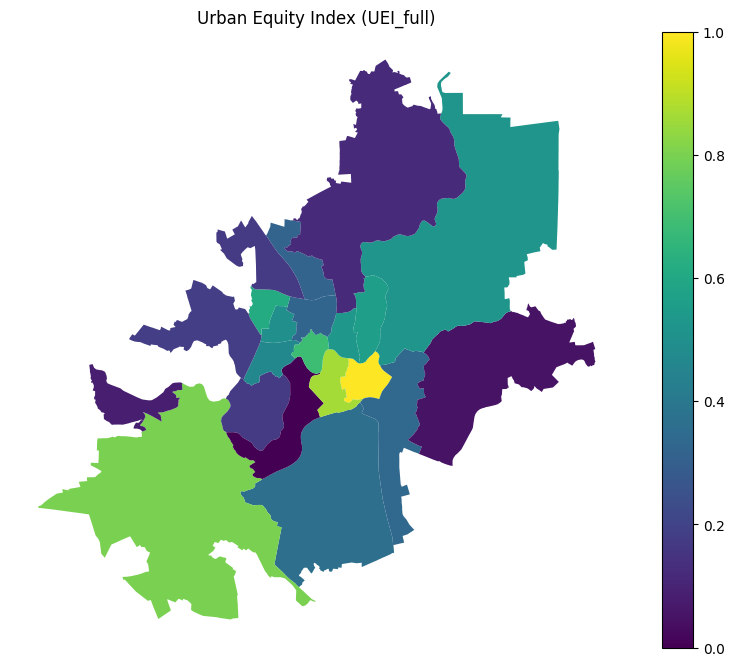

In [400]:
ax = uei.plot(column="UEI_full", legend=True, figsize=(10, 8))
plt.title("Urban Equity Index (UEI_full)")
plt.axis("off")
plt.show()